# Debug the intervention feature

In [ ]:
!git clone https://github.com/mGarbowski/zzsn-projekt.git
!cd zzsn-projekt && git checkout intervention

In [ ]:
import os
os.chdir('zzsn-projekt')
os.getcwd()

In [9]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
from diffusers import StableDiffusionPipeline
model_id = "CompVis/stable-diffusion-v1-4"
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=dtype)
pipe = pipe.to(device)
pipe.set_progress_bar_config(disable=True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
from models.linear import SchmidhuberLinear, SchmidhuberLinearConfig
loaded_state = torch.load("../example_weights.pt", map_location="cpu")
loaded_state.keys()
cfg = SchmidhuberLinearConfig(
    expansion_factor=2,
    input_dim=1280,
    predictor_dropout=0.3,
    predictor_embedding_dim=128,
    predictor_hidden_dims=[256]
)
schmidhuber = SchmidhuberLinear(cfg)
schmidhuber.load_state_dict(loaded_state)
schmidhuber = schmidhuber.to(device).to(dtype)

In [12]:
from models.diffusion import WrappedDiffusion, GenerationParams
wrapped = WrappedDiffusion(pipe, schmidhuber)
params =GenerationParams(
    prompt="A picture of grey british shorthair cat",
    num_inference_steps=50,
    guidance_scale=7.5
)

## Image without intervention

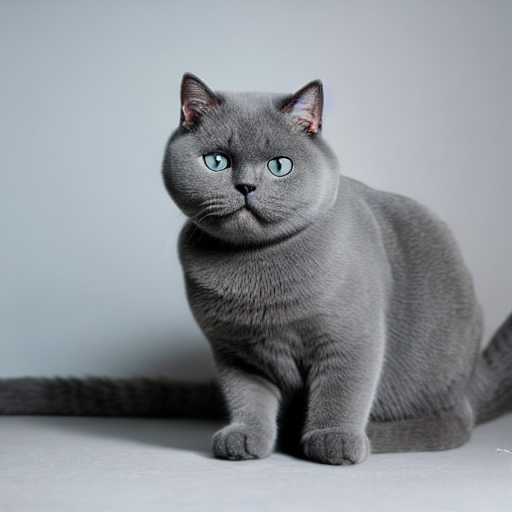

In [14]:
res1 = wrapped.diffusion(params.prompt, num_inference_steps=params.num_inference_steps,guidance_scale=params.guidance_scale)
res1.images[0]

## Image with intervention

In [15]:
intervention_multipliers = {
    key: 0 for key in range(10, 50)
}
res2 = wrapped.generate_with_intervention(params, intervention_multipliers)

RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Half

In [ ]:
res2.images[0]